# Generator Comparison

In [126]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [127]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial

# local imports
import sys
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana') # absolute path for running on EAF
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.unfolding.wienersvd import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

In [128]:
save_fig = False
show_plot = True

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"generator_comparison-{today_str}")

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

# Cross section model comparisons

In [132]:
branches_nu = ["PDGnu", "cc", "Enu_true", "tgt", "ELep", "fScaleFactor", "RWWeight", "Mode",
                       "Q2", "q0", "q3", "x", "y",
                       "W_nuc_rest", "W", "W_genie", "flagCC0pi", 'Weight',
              "CosThetaAdler", "PhiAdler", "dalphat", "dpt", "dphit", "pnreco_C"]

branches_trk = ["pdg", "px", "py", "pz", "E"]

In [133]:
def get_trk_info(nudf, trkdf, det="SBND"):
    ntrks = trkdf.pdg.groupby(level=[0]).count()
    nudf["ntrks"] = ntrks

    if det == "SBND":
        for pid, pname, pth in zip([13, 2212, 211, 111], 
                                                              ["mu", "proton", "pi", "pi0"], 
                                                              [0.22, 0.3, 0.07, 0]):
            print(pid, pname, pth)
        
            leading = trkdf[trkdf.pdg == pid].groupby(level=[0]).head(1)
            leading_p = np.sqrt(leading.px**2 + leading.py**2 + leading.pz**2)
            leading_dirx = leading.px / leading_p
            leading_diry = leading.py / leading_p
            leading_dirz = leading.pz / leading_p
            
            leading_p.name = "{}_p".format(pname)
            nudf = nudf.join(leading_p.reset_index(level=[1])["{}_p".format(pname)])
            
            leading_dirx.name = "{}_dirx".format(pname)
            nudf = nudf.join(leading_dirx.reset_index(level=[1])["{}_dirx".format(pname)])
            leading_diry.name = "{}_diry".format(pname)
            nudf = nudf.join(leading_diry.reset_index(level=[1])["{}_diry".format(pname)])
            leading_dirz.name = "{}_dirz".format(pname)
            nudf = nudf.join(leading_dirz.reset_index(level=[1])["{}_dirz".format(pname)])

            ntrks = trkdf[(np.abs(trkdf.pdg) == pid) & (np.sqrt(trkdf.px**2 + trkdf.py**2 + trkdf.pz**2) > pth)].pdg.groupby(level=[0]).count()
            nudf["n{}s".format(pname)] = ntrks

    if det == "MicroBooNE":
        for pid, pname, pth in zip([13, 2212, 211, 111], 
                                                              ["mu", "proton", "pi", "pi0"], 
                                                              [0.1, 0.3, 0.07, 0]):
            print(pid, pname, pth)
        
            leading = trkdf[trkdf.pdg == pid].groupby(level=[0]).head(1)
            leading_p = np.sqrt(leading.px**2 + leading.py**2 + leading.pz**2)
            leading_dirx = leading.px / leading_p
            leading_diry = leading.py / leading_p
            leading_dirz = leading.pz / leading_p
            
            leading_p.name = "{}_p".format(pname)
            nudf = nudf.join(leading_p.reset_index(level=[1])["{}_p".format(pname)])
            
            leading_dirx.name = "{}_dirx".format(pname)
            nudf = nudf.join(leading_dirx.reset_index(level=[1])["{}_dirx".format(pname)])
            leading_diry.name = "{}_diry".format(pname)
            nudf = nudf.join(leading_diry.reset_index(level=[1])["{}_diry".format(pname)])
            leading_dirz.name = "{}_dirz".format(pname)
            nudf = nudf.join(leading_dirz.reset_index(level=[1])["{}_dirz".format(pname)])

            ntrks = trkdf[(np.abs(trkdf.pdg) == pid) & (np.sqrt(trkdf.px**2 + trkdf.py**2 + trkdf.pz**2) > pth)].pdg.groupby(level=[0]).count()
            nudf["n{}s".format(pname)] = ntrks

    return nudf

In [134]:
def get_signal(df, det="SBND"):
    if det == "SBND":
        numuCC = (df.PDGnu == 14) & (df.cc == 1)
        topology = (df.nmus == 1) & (df.nprotons == 1) & (np.nan_to_num(df.npis, nan=0) == 0) & (np.nan_to_num(df.npi0s, nan=0) == 0)
        kinematics = (df.mu_p > 0.22) & (df.mu_p < 1.) & (df.proton_p > 0.3) & (df.proton_p < 1.)

    elif det == "MicroBooNE":
        numuCC = (df.PDGnu == 14) & (df.cc == 1)
        topology = (df.nmus == 1) & (df.nprotons == 1) & (np.nan_to_num(df.npis, nan=0) == 0) & (np.nan_to_num(df.npi0s, nan=0) == 0)
        kinematics = (df.mu_p > 0.1) & (df.mu_p < 1.2) & (df.proton_p > 0.3) & (df.proton_p < 1.)

    return numuCC & topology & kinematics

## Flux comparisons

In [136]:
file_dir = "/exp/sbnd/data/users/munjung/xsec/flux_closure"

nom_filename = file_dir + "/14_1000180400_CCQE_v3_6_0_AR23_20i_00_000_-nomflux.flat.root"
events = uproot.open(nom_filename+":FlatTree_VARS")
nom_nus = events.arrays(branches_nu, library="pd")
nom_trks = events.arrays(branches_trk, library="pd")
nom_nus = get_trk_info(nom_nus, nom_trks)

dk2nu_filename = file_dir + "/14_1000180400_CCQE_v3_6_0_AR23_20i_00_000_-dk2nuflux.flat.root"
events = uproot.open(dk2nu_filename+":FlatTree_VARS")
dk2nu_nus = events.arrays(branches_nu, library="pd")
dk2nu_trks = events.arrays(branches_trk, library="pd")
dk2nu_nus = get_trk_info(dk2nu_nus, dk2nu_trks)

/home/munjung/.conda/envs/cohpi2/lib/python3.9/site-packages/uproot/interpretation/library.py:747: FutureWarning: MultiIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if hasattr(index, "is_integer") and index.is_integer():


13 mu 0.22
2212 proton 0.3
211 pi 0.07
111 pi0 0


/home/munjung/.conda/envs/cohpi2/lib/python3.9/site-packages/uproot/interpretation/library.py:747: FutureWarning: MultiIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if hasattr(index, "is_integer") and index.is_integer():


13 mu 0.22
2212 proton 0.3
211 pi 0.07
111 pi0 0


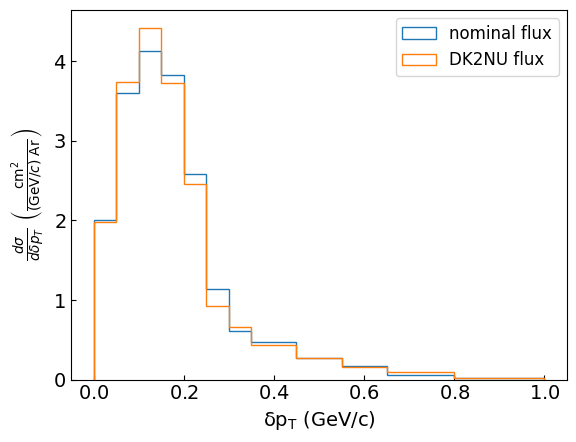

In [146]:
# var_config = VariableConfig.muon_momentum()
# var_branch = "mu_p"

var_config = VariableConfig.tki_del_Tp()
var_branch = "dpt"

nevts_dict = {}
for gendf, genname in zip([nom_nus, dk2nu_nus], ["nominal flux", "DK2NU flux"]):

    signal = gendf[get_signal(gendf)]
    var = signal[var_branch] / 1e3 # * 180/np.pi
    # clip
    var = np.clip(var, var_config.bins[0], var_config.bins[-1])

    bins = var_config.bins
    bin_centers = var_config.bin_centers
    bin_width = np.diff(bins)

    weights = 40 * signal.fScaleFactor * signal.Weight  #/ bin_width
    
    # bins = np.linspace(0,1,51)
    n, bins = np.histogram(var, bins=bins, weights=weights)

    # n, bins, _ = plt.hist(bin_centers, bins=bins, weights=1.01*n / bin_width, histtype="step", label=genname)
    n, bins, _ = plt.hist(bin_centers, bins=bins, weights=n, histtype="step", label=genname, density=True)
    nevts_dict[genname] = n
     
plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend(fontsize=12)

# save_name = "{}/{}-generator_comparison.pdf".format(save_fig_dir, var_config.var_save_name)
# plt.savefig(save_name, bbox_inches="tight", dpi=300)
plt.show();

In [16]:
file_dir = "/scratch/7DayLifetime/munjung/xsec/generators"

# gibuu_filename = file_dir + "/GiBUU2025.flat.root"
# events = uproot.open(gibuu_filename+":FlatTree_VARS")
# gibuu_nus = events.arrays(branches_nu, library="pd")
# gibuu_trks = events.arrays(branches_trk, library="pd")

genie_filename = file_dir + "/14_1000180400_CC_v3_6_2_AR23_20i_00_000.flat.root"
events = uproot.open(genie_filename+":FlatTree_VARS")
genie_nus = events.arrays(branches_nu, library="pd")
genie_trks = events.arrays(branches_trk, library="pd")

# neut_filename = file_dir + "/bnb.sbnd.neut_5_8_0_0.flat.root"
# events = uproot.open(neut_filename+":FlatTree_VARS")
# neut_nus = events.arrays(branches_nu, library="pd")
# neut_trks = events.arrays(branches_trk, library="pd")

# nuwro_filename = file_dir + "/bnb.sbnd.nuwro_25_03_1.flat.root"
# events = uproot.open(nuwro_filename+":FlatTree_VARS")
# nuwro_nus = events.arrays(branches_nu, library="pd")
# nuwro_trks = events.arrays(branches_trk, library="pd")

# genie_ar25_filename = file_dir + "/14_1000180400_CC_v3_6_2_AR25_20i_00_000.flat.root"
# events = uproot.open(genie_ar25_filename+":FlatTree_VARS")
# genie_ar25_nus = events.arrays(branches_nu, library="pd")
# genie_ar25_trks = events.arrays(branches_trk, library="pd")

/home/munjung/.conda/envs/cohpi2/lib/python3.9/site-packages/uproot/interpretation/library.py:747: FutureWarning: MultiIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if hasattr(index, "is_integer") and index.is_integer():


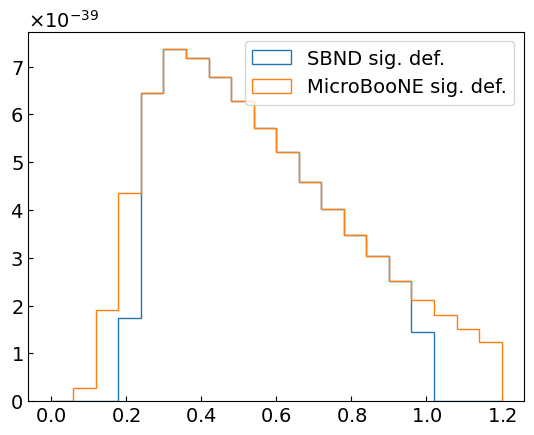

In [22]:
var_config = VariableConfig.muon_momentum()
var_branch = "mu_p"

# df_sbnd = get_trk_info(genie_nus, genie_trks)
signal = df_sbnd[get_signal(df_sbnd)]
var = signal[var_branch] #/ 1e3 # * 180/np.pi

# var = np.clip(var, var_config.bins[0], var_config.bins[-1])
bins = np.linspace(0, 1.2, 21)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = np.diff(bins)
weights = 40 * signal.fScaleFactor * signal.Weight  #/ bin_width
n, bins = np.histogram(var, bins=bins, weights=weights)
n_sbnd, bins, _ = plt.hist(bin_centers, bins=bins, weights=n, histtype="step", label="SBND sig. def.")

# df_mb = get_trk_info(genie_nus, genie_trks, det="MicroBooNE")
signal = df_mb[get_signal(df_mb, det="MicroBooNE")]
var = signal[var_branch] #/ 1e3 # * 180/np.pi

# var = np.clip(var, var_config.bins[0], var_config.bins[-1])
weights = 40 * signal.fScaleFactor * signal.Weight  #/ bin_width
n, bins = np.histogram(var, bins=bins, weights=weights)
n_mb, bins, _ = plt.hist(bin_centers, bins=bins, weights=n, histtype="step", label="MicroBooNE sig. def.")

plt.legend()
plt.show();

In [23]:
n_sbnd.sum() / n_mb.sum()

0.8677486165704966

In [8]:
gibuu_nus = get_trk_info(gibuu_nus, gibuu_trks)
genie_nus = get_trk_info(genie_nus, genie_trks)
genie_ar25_nus = get_trk_info(genie_ar25_nus, genie_ar25_trks)
# genie_bugfix_nus = get_trk_info(genie_bugfix_nus, genie_bugfix_trks)
# genie_bugfix_lqcd_nus = get_trk_info(genie_bugfix_lqcd_nus, genie_bugfix_lqcd_trks)
# genie_bugfix_minerva_nus = get_trk_info(genie_bugfix_minerva_nus, genie_bugfix_minerva_trks)
neut_nus = get_trk_info(neut_nus, neut_trks)
nuwro_nus = get_trk_info(nuwro_nus, nuwro_trks)

13 mu 0.22
2212 proton 0.3
211 pi 0.07
111 pi0 0
13 mu 0.22
2212 proton 0.3
211 pi 0.07
111 pi0 0
13 mu 0.22
2212 proton 0.3
211 pi 0.07
111 pi0 0
13 mu 0.22
2212 proton 0.3
211 pi 0.07
111 pi0 0
13 mu 0.22
2212 proton 0.3
211 pi 0.07
111 pi0 0


In [44]:
infvflux_file = "/exp/sbnd/data/users/munjung/xsec/flux_closure/ar23.pkl"
with open(infvflux_file, "rb") as f:
    pkl_data = pickle.load(f)

signal_df = pkl_data[(pkl_data.n_mu_220MeVc == 1) & (pkl_data.n_p_300MeVc == 1 ) & (pkl_data.n_p_300MeVc_add == 1 )  & (pkl_data.n_cpi_70MeVc == 0) & (pkl_data.n_pi0_0MeV == 0)]
signal_df["x"] = signal_df.vtx_x * 100
signal_df["y"] = signal_df.vtx_y * 100
signal_df["z"] = signal_df.vtx_z * 100
signal_df = signal_df[InFV(signal_df, det="SBND_nohighyz")]

/tmp/ipykernel_550985/3176448920.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  signal_df["x"] = signal_df.vtx_x * 100
/tmp/ipykernel_550985/3176448920.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  signal_df["y"] = signal_df.vtx_y * 100
/tmp/ipykernel_550985/3176448920.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [45]:
# choose a variable to unfold, defined in variable_configs.py
var_config = VariableConfig.muon_momentum()
var_branch = "mu_p"
# var_config = VariableConfig.muon_direction()
# var_config = VariableConfig.proton_momentum()
# var_config = VariableConfig.proton_direction()
# var_config = VariableConfig.tki_del_Tp()
# var_branch = "dpt"
# var_config = VariableConfig.tki_del_alpha()
# var_branch = "dalphat"
# var_config = VariableConfig.tki_del_phi()
# var_branch = "dphit"

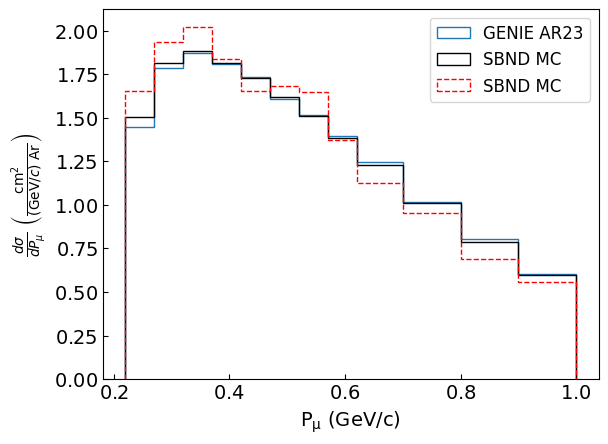

In [47]:
# plt.hist(df[mask].dpt / 1e3, bins=var_config.bins, weights=40 * df[mask].fScaleFactor * df[mask].Weight / bin_width, histtype="step", label=label)
nevts_dict = {}
# for gendf, genname in zip([genie_nus, genie_ar25_nus, gibuu_nus, nuwro_nus, neut_nus], ["GENIE AR23", "GENIE AR25", "GiBUU", "NuWro", "NEUT"]):
for gendf, genname in zip([genie_nus], ["GENIE AR23"]):

    signal = gendf[get_signal(gendf)]
    var = signal[var_branch] #/ 1e3 # * 180/np.pi
    # clip
    var = np.clip(var, var_config.bins[0], var_config.bins[-1])

    bins = var_config.bins
    bin_centers = var_config.bin_centers
    bin_width = np.diff(bins)

    if genname == "GiBUU":
        scale = 500
    else:
        scale = 1
        
    weights = 40 * signal.fScaleFactor * signal.Weight / scale  #/ bin_width
    
    # bins = np.linspace(0,1,51)
    n, bins = np.histogram(var, bins=bins, weights=weights)

    # n, bins, _ = plt.hist(bin_centers, bins=bins, weights=1.01*n / bin_width, histtype="step", label=genname)
    n, bins, _ = plt.hist(bin_centers, bins=bins, weights=n, histtype="step", label=genname, density=True)
    nevts_dict[genname] = n
     

# sbn_prod = np.array([5.31600254e-39, 1.13061712e-38, 1.29190521e-38, 1.17979543e-38,
#        8.56204978e-39, 4.54729493e-39, 3.26735628e-39, 5.18349562e-39,
#        3.53553391e-39, 2.19529717e-39, 1.51070912e-39, 5.25468087e-40])

sbn_prod = np.array([5.30623202e-39, 6.40285702e-39, 6.64283970e-39, 6.41160397e-39,
       6.09736530e-39, 5.72869086e-39, 5.32893685e-39, 4.89726580e-39,
       6.94442321e-39, 7.13629769e-39, 5.55421722e-39, 4.21565543e-39]) #* 0.95
# plt.hist(bin_centers, bins=bins, weights=sbn_prod/bin_width, histtype="step", label="SBND MC", color="black")
plt.hist(bin_centers, bins=bins, weights=sbn_prod, histtype="step", label="SBND MC", color="black", density=True)

plt.hist(signal_df.muon_p, bins=bins, histtype="step", label="SBND MC", color="red", density=True, linestyle="--")

plt.xlabel(var_config.var_labels[0])
plt.ylabel(var_config.xsec_label)
plt.legend(fontsize=12)

# save_name = "{}/{}-generator_comparison.pdf".format(save_fig_dir, var_config.var_save_name)
# plt.savefig(save_name, bbox_inches="tight", dpi=300)
plt.show();

In [265]:
save_results_dir = "/exp/sbnd/data/users/munjung/xsec/DATA_RESULTS"
np.save(f"{save_results_dir}/{var_config.var_save_name}-nevts_dict.npy", nevts_dict)

In [279]:
nevts_dict["GENIE AR23"]

array([5.63214194e-39, 1.17155555e-38, 1.31107044e-38, 1.17549445e-38,
       8.07158591e-39, 3.75338349e-39, 2.49488035e-39, 3.87276622e-39,
       2.50022947e-39, 1.52206910e-39, 1.02922020e-39, 3.50367662e-40])